# ============================================================
# Credit Risk Analysis 
# ============================================================

## Business Problem

Financial institutions such as banks and NBFCs face significant financial losses due to loan defaults. Approving loans without accurately assessing a customer’s creditworthiness increases the risk of non-repayment, while overly strict approval criteria may lead to loss of potential customers and revenue.

---

### 🔹 Objective
The objective of this project is to analyze customer demographic, financial, and credit history data to identify key factors influencing loan default and to build a data-driven approach that helps predict the likelihood of default.

---

### 🔹 Key Goals
- Identify high-risk customers based on financial and behavioral attributes  
- Analyze the impact of factors such as:  
  - Income  
  - Loan amount  
  - Credit history  
  - Employment length  
- Reduce financial risk for the institution  
- Support better loan approval decisions





In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("credit_risk_dataset.csv")

df.head()



,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n--- Data types ---")
print(df.dtypes)

print("\n--- Missing values ---")
print(df.isnull().sum())

print("\n--- Target distribution ---")
print(df['loan_status'].value_counts())
print(df['loan_status'].value_counts(normalize=True).round(3))

df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
# Median imputation by loan grade
df['loan_int_rate'] = df.groupby('loan_grade')['loan_int_rate'].transform(
    lambda x: x.fillna(x.median())
)
print("\n")
print(df.isnull().sum())

# Convert categorical columns properly
df['person_home_ownership'] = df['person_home_ownership'].astype('category')
df['loan_intent'] = df['loan_intent'].astype('category')
df['loan_grade'] = df['loan_grade'].astype('category')

df.duplicated().sum()

df = df.drop_duplicates()

Rows: 32581, Columns: 12

--- Data types ---
person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object

--- Missing values ---
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

--- Target distribution ---

{'person_age': 1491, 'person_income': 1478, 'person_emp_length': 852, 'loan_amnt': 1679, 'loan_int_rate': 6, 'loan_percent_income': 650, 'cb_person_cred_hist_length': 1139}


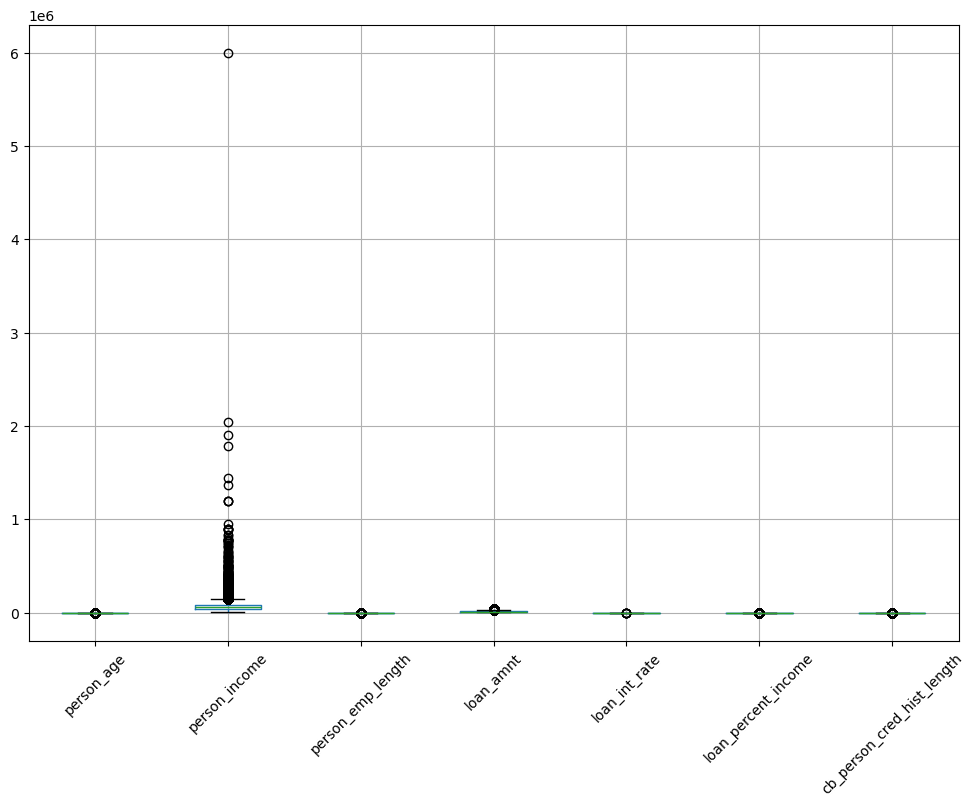

<class 'pandas.core.frame.DataFrame'>
Index: 32409 entries, 1 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   person_age                  32409 non-null  int64   
 1   person_income               32409 non-null  float64 
 2   person_home_ownership       32409 non-null  category
 3   person_emp_length           32409 non-null  float64 
 4   loan_intent                 32409 non-null  category
 5   loan_grade                  32409 non-null  category
 6   loan_amnt                   32409 non-null  float64 
 7   loan_int_rate               32409 non-null  float64 
 8   loan_status                 32409 non-null  int64   
 9   loan_percent_income         32409 non-null  float64 
 10  cb_person_default_on_file   32409 non-null  object  
 11  cb_person_cred_hist_length  32409 non-null  int64   
dtypes: category(3), float64(5), int64(3), object(1)
memory usage: 2.6+ MB


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32409.000000,32409.000000,32409.000000,32409.000000,32409.000000,32409.000000,32409.000000,32409.000000
mean,27.730754,62427.330649,4.761424,9417.402573,11.020010,0.218705,0.168857,5.811194
std,6.210445,31800.814798,3.983757,5827.558597,3.213459,0.413374,0.102382,4.057899
min,20.000000,4000.000000,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,38500.000000,2.000000,5000.000000,7.880000,0.000000,0.090000,3.000000
50%,26.000000,55000.000000,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,79200.000000,7.000000,12250.000000,13.480000,0.000000,0.230000,8.000000
max,94.000000,140250.000000,41.000000,23125.000000,23.220000,1.000000,0.440000,30.000000


In [4]:
#outlier detection

numeric_cols = ['person_age','person_income','person_emp_length',
                'loan_amnt','loan_int_rate','loan_percent_income',
                'cb_person_cred_hist_length']

outliers_dict = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_dict[col] = len(outliers)

print(outliers_dict)


plt.figure(figsize=(12,8))
df[numeric_cols].boxplot()
plt.xticks(rotation=45)
plt.show()


# Age filter
df = df[df['person_age'] <= 100]

df.loc[df['person_age'] > 100, 'person_age'] = 100

# Employment length
df = df[(df['person_emp_length'] >= 0) & (df['person_emp_length'] <= 50)]

# Credit history logical rule
df = df[df['cb_person_cred_hist_length'] <= df['person_age']]

# Function for capping
def cap_outliers(col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    return np.where(df[col] > upper, upper, df[col])

# Apply capping
cols_to_cap = ['person_income', 'loan_amnt', 'loan_percent_income']

for col in cols_to_cap:
    df[col] = cap_outliers(col)

df.info()
df.describe()




Exploratory data analysis



Default Rate: 0.2187046807985436


C:\Users\hp\AppData\Local\Temp\ipykernel_2820\2515933610.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('person_home_ownership')['loan_status'].mean().sort_values(ascending=False)


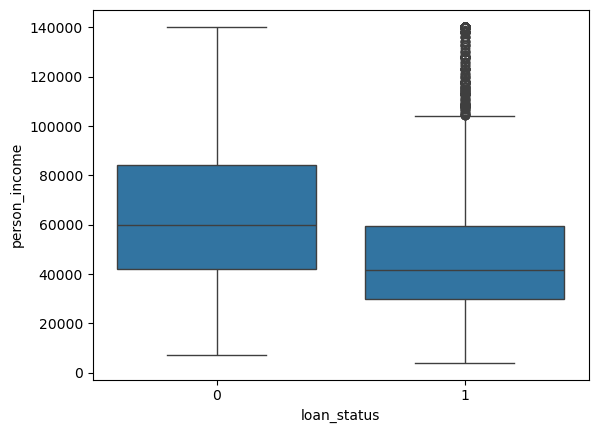

In [9]:
#Default Rate Analysis
default_rate = df['loan_status'].mean()
print("Default Rate:", default_rate)

#Segment-wise Default Rate
df.groupby('person_home_ownership')['loan_status'].mean().sort_values(ascending=False)

#Income vs Default
df.groupby('loan_status')['person_income'].mean()

sns.boxplot(x='loan_status', y='person_income', data=df)
plt.show()


C:\Users\hp\AppData\Local\Temp\ipykernel_2820\3875255231.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loan_means.index, y=loan_means.values, palette="viridis")


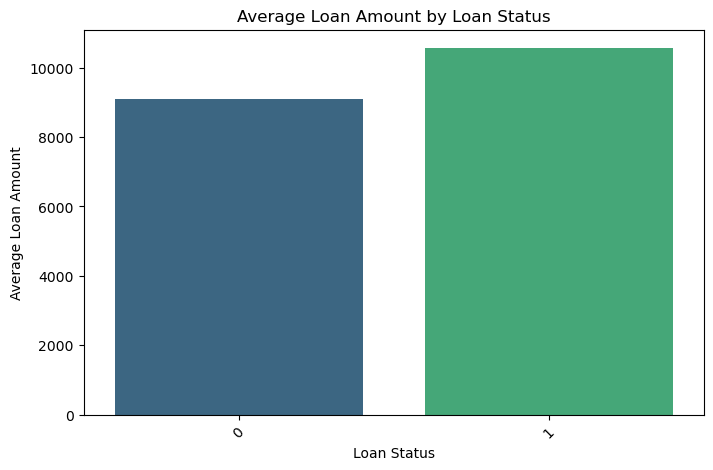

In [22]:

loan_means=df.groupby('loan_status')['loan_amnt'].mean()

plt.figure(figsize=(8,5))
sns.barplot(x=loan_means.index, y=loan_means.values, palette="viridis")

plt.title("Average Loan Amount by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Average Loan Amount")
plt.xticks(rotation=45)
plt.show()

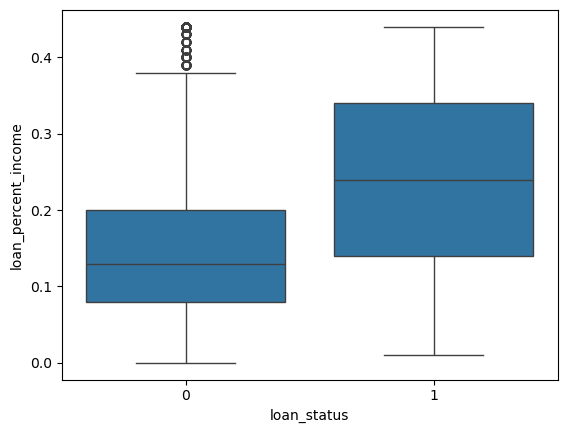

In [12]:
#Loan-to-Income Ratio
df.groupby('loan_status')['loan_percent_income'].mean()

sns.boxplot(x='loan_status', y='loan_percent_income', data=df)
plt.show()

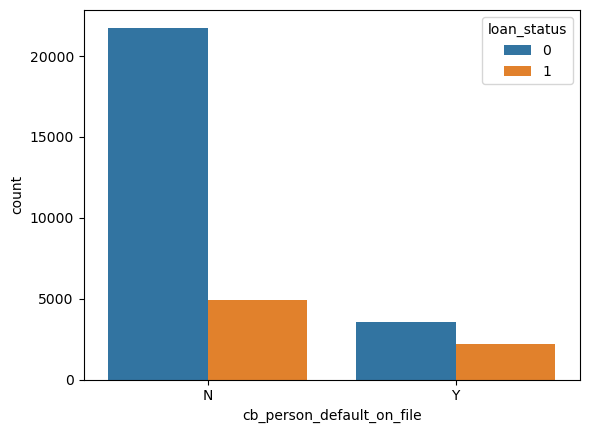

In [13]:
#Previous Default Impact

df.groupby('cb_person_default_on_file')['loan_status'].mean()

sns.countplot(x='cb_person_default_on_file', hue='loan_status', data=df)
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_2820\187976491.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=emp_means.index, y=emp_means.values, palette="coolwarm")


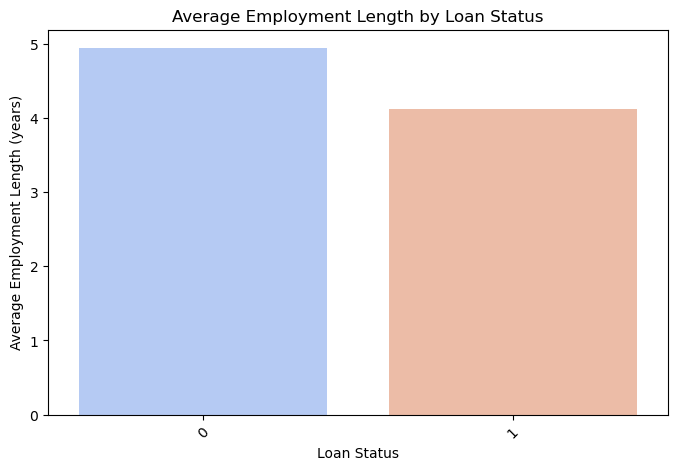

C:\Users\hp\AppData\Local\Temp\ipykernel_2820\187976491.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  intent_risk = df.groupby('loan_intent')['loan_status'].mean().sort_values(ascending=False)
C:\Users\hp\AppData\Local\Temp\ipykernel_2820\187976491.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=intent_risk.index, y=intent_risk.values, palette="magma")


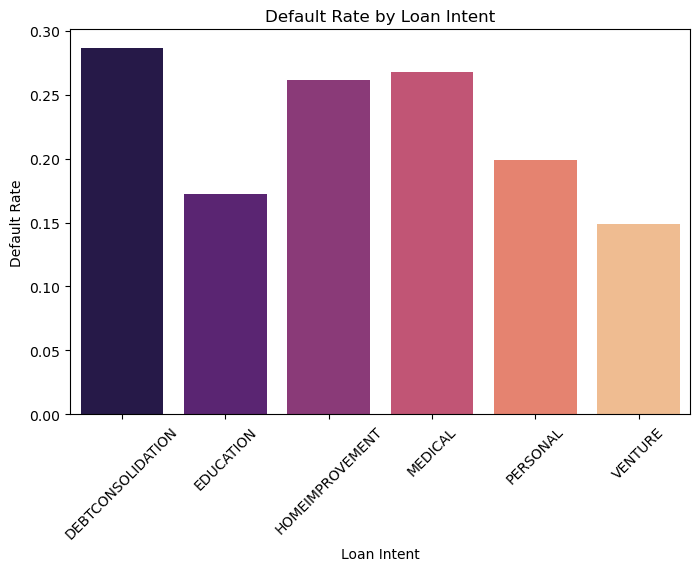

In [23]:
#Employment Length Analysis

emp_means = df.groupby('loan_status')['person_emp_length'].mean()

plt.figure(figsize=(8,5))
sns.barplot(x=emp_means.index, y=emp_means.values, palette="coolwarm")

plt.title("Average Employment Length by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Average Employment Length (years)")
plt.xticks(rotation=45)
plt.show()
#Loan Intent Risk Analysis

intent_risk = df.groupby('loan_intent')['loan_status'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=intent_risk.index, y=intent_risk.values, palette="magma")

plt.title("Default Rate by Loan Intent")
plt.xlabel("Loan Intent")
plt.ylabel("Default Rate")
plt.xticks(rotation=45)
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_2820\572869298.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grade_risk = df.groupby('loan_grade')['loan_status'].mean().sort_values(ascending=False)
C:\Users\hp\AppData\Local\Temp\ipykernel_2820\572869298.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=grade_risk.index, y=grade_risk.values, palette="plasma")


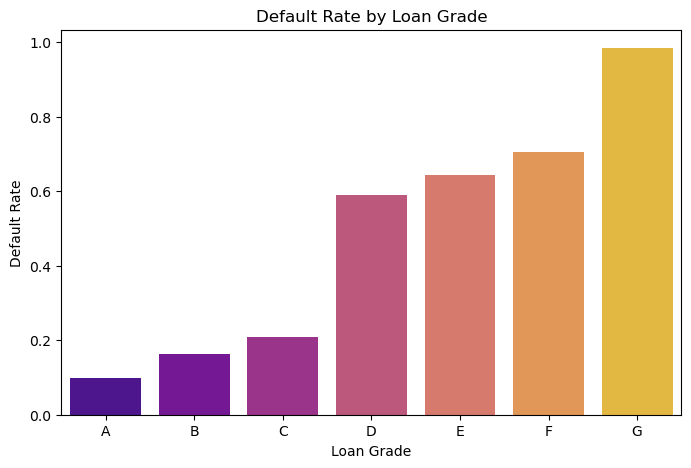

In [24]:

# Calculate default rate by loan grade
grade_risk = df.groupby('loan_grade')['loan_status'].mean().sort_values(ascending=False)

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x=grade_risk.index, y=grade_risk.values, palette="plasma")

plt.title("Default Rate by Loan Grade")
plt.xlabel("Loan Grade")
plt.ylabel("Default Rate")
plt.show()

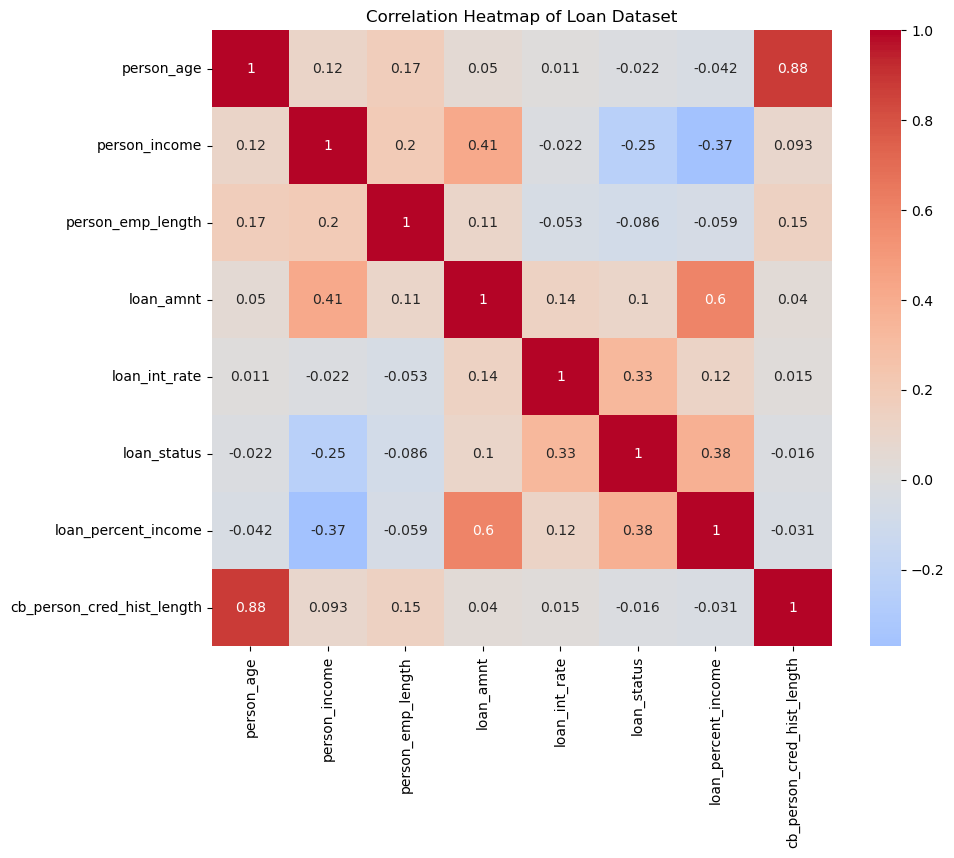

In [27]:
# Correlation with loan_status
corrs = df.corr(numeric_only=True)['loan_status'].sort_values(ascending=False)

# Plot
corr_matrix = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)

plt.title("Correlation Heatmap of Loan Dataset")
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_2820\3808843736.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_means = df.groupby('risk_segment')['loan_status'].mean()
C:\Users\hp\AppData\Local\Temp\ipykernel_2820\3808843736.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=risk_means.index, y=risk_means.values, palette="inferno")


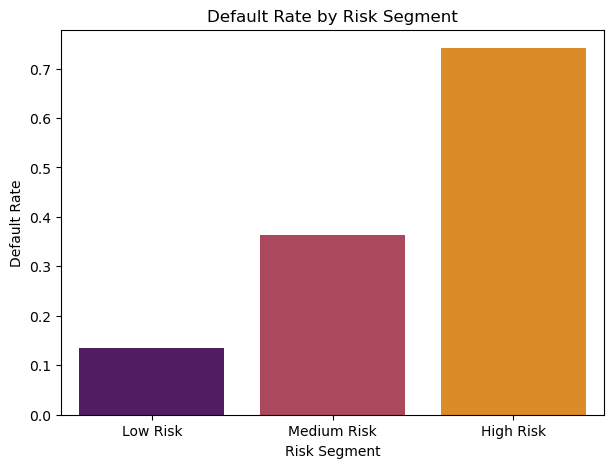

In [29]:
df['risk_segment'] = pd.cut(df['loan_percent_income'],
                           bins=[0, 0.2, 0.4, 1],
                           labels=['Low Risk', 'Medium Risk', 'High Risk'])

# Group by risk segment and calculate default rate
risk_means = df.groupby('risk_segment')['loan_status'].mean()

# Plot
plt.figure(figsize=(7,5))
sns.barplot(x=risk_means.index, y=risk_means.values, palette="inferno")

plt.title("Default Rate by Risk Segment")
plt.xlabel("Risk Segment")
plt.ylabel("Default Rate")
plt.show()

Key Insights

Customers with high loan-to-income ratio have significantly higher default rates
Customers with previous defaults are high-risk applicants
Low-income groups are more likely to default
Certain loan purposes (e.g., personal loans) carry higher risk
Lower loan grades are strongly associated with defaults


💼 Business Recommendations


Reject high loan-to-income ratio customers
Apply stricter rules for customers with past defaults
Offer smaller loans to low-income applicants
Adjust interest rates based on risk segment